In [71]:
#!pip install spectral-cube
#!pip install astroquery
#!pip install reproject

In [102]:
import glob #importing glob library
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

import astropy
import astropy.units as u
from astropy.utils.data import download_file
from astropy.io import fits  # We use fits to open the actual data file
from astropy.utils import data
from astropy.wcs import wcs
from astropy.coordinates import SkyCoord

import ipywidgets as widgets
from IPython.display import display

In [55]:
fits_files = glob.glob('C:/Users/jules/OneDrive/Desktop/Research Test Files/*.fit')
fits_files

['C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-001.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-002.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-003.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-004.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-005.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-006.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-007.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-008.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-009.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-010.fit']

In [56]:
fits_dict = {}

for i, fn in enumerate(fits_files):
    key = f"file_{i+1}"
    fits_dict[key] = fn

fits_dict

{'file_1': 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-001.fit',
 'file_2': 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-002.fit',
 'file_3': 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-003.fit',
 'file_4': 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-004.fit',
 'file_5': 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-005.fit',
 'file_6': 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-006.fit',
 'file_7': 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-007.fit',
 'file_8': 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-008.fit',
 'file_9': 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-009.fit',
 'file_10': 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-010.fit'}

In [53]:
def search_file(search_query, fits_dict):
    file_ret = fits_dict.get(search_query)
    if file_ret is None:
        print(f"Error: Key '{search_query}' not found in the dictionary.")
    return file_ret

search_file('file_1', fits_dict)

'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-001.fit'

Filename: C:/Users/jules/OneDrive/Desktop/Research Test Files\lab2-001.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      42   (512, 512)   int16 (rescales to uint16)   
None
SIMPLE  =                    T                                                  
BITPIX  =                   16 /8 unsigned int, 16 & 32 int, -32 & -64 real     
NAXIS   =                    2 /number of axes                                  
NAXIS1  =                  512 /fastest changing axis                           
NAXIS2  =                  512 /next to fastest changing axis                   
BSCALE  =   1.0000000000000000 /physical = BZERO + BSCALE*array_value           
BZERO   =   32768.000000000000 /physical = BZERO + BSCALE*array_value           
DATE-OBS= '2018-03-20T01:47:42' /YYYY-MM-DDThh:mm:ss observation start, UT      
EXPTIME =   90.000000000000000 /Exposure time in seconds                        
EXPOSURE=   90.000000000000000 /Exposure tim

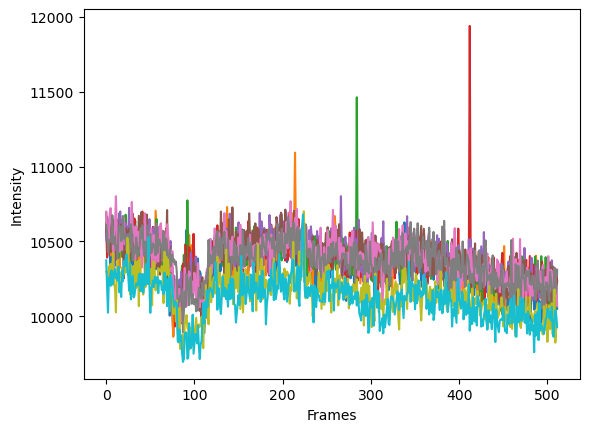

In [58]:
for i in range(0, len(fits_files)):
    hdul = fits.open(fits_files[i])
    print(hdul.info())
    data = hdul[0].data
    print(repr(hdul[0].header))
    print(data[i])
    plt.plot(data[i])
    plt.xlabel('Frames')
    plt.ylabel('Intensity')

In [76]:
cube = np.zeros((len(fits_files),512,512))

for i, fn in enumerate(fits_files):
    hdu = fits.open(fn)
    data = hdu[0].data[:,:]
    cube[i,:,:] = data

hdu_new = fits.PrimaryHDU(cube)
hdu_new.writeto('cube.fits', overwrite=True)

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'cube.fits'

In [77]:
hdu_cube = fits.open('cube.fits', overwrite = True)
print(hdu_cube.info())
data = hdu_cube[0].data
print(data)

Filename: cube.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (512, 512, 10)   float64   
None
[[[10594. 10488. 10544. ... 10283. 10184. 10049.]
  [10553. 10535. 10468. ... 10035. 10107. 10054.]
  [10662. 10294. 10611. ... 10039. 10245. 10027.]
  ...
  [10731. 10739. 10729. ... 10504. 10444. 10639.]
  [11070. 10627. 10714. ... 10681. 10499. 10685.]
  [10871. 10786. 10546. ... 10546. 10642. 10630.]]

 [[10619. 10686. 10433. ... 10292. 10197. 10162.]
  [10602. 10510. 10411. ... 10224. 10156. 10090.]
  [10751. 10397. 10669. ... 10237. 10294. 10152.]
  ...
  [10757. 10693. 10755. ... 10674. 10738. 10665.]
  [10702. 10797. 10635. ... 10597. 10576. 10654.]
  [10718. 10916. 10654. ... 10437. 10718. 10698.]]

 [[10531. 10458. 10546. ... 10094. 10047. 10286.]
  [10534. 10686. 10366. ... 10157. 10167. 10032.]
  [10621. 10483. 10429. ... 10001. 10199. 10297.]
  ...
  [10906. 10774. 10646. ... 10716. 10770. 10777.]
  [10940. 10757. 1077

In [66]:
for i in range(len(fits_files)):
    hdul_norm = fits.open(fits_files[i])
    data_org = hdul_norm[0].data
    data_max = np.max(hdul_norm[0].data)
    data_norm = data_org / data_max
    norm_fits = print(data_norm[i])

[0.20949594 0.20739979 0.20850719 0.20823034 0.20621329 0.20263402
 0.2049477  0.20666812 0.20892246 0.20917954 0.20445332 0.20838854
 0.20668789 0.20868516 0.20765686 0.20761731 0.20927841 0.20791394
 0.20858629 0.20953549 0.20401827 0.20496747 0.20846764 0.20957504
 0.20747889 0.20961459 0.20662857 0.20386007 0.20682632 0.20441377
 0.20682632 0.20457197 0.20542229 0.20757777 0.20641104 0.20504657
 0.20876426 0.20652969 0.20757777 0.20745912 0.20625284 0.20767664
 0.20722182 0.20652969 0.20690542 0.20852696 0.20919931 0.2049477
 0.20923886 0.20779529 0.20558049 0.2044731  0.20724159 0.20656924
 0.20755799 0.20629239 0.2039194  0.20821056 0.20546184 0.20522454
 0.2047895  0.20898179 0.20759754 0.2042358  0.20900156 0.20518499
 0.20672744 0.20184303 0.20714272 0.20370187 0.20261425 0.20573869
 0.19780893 0.20156618 0.19826376 0.19816488 0.19521841 0.19972711
 0.19907453 0.19763096 0.19865926 0.2003599  0.20093338 0.2007554
 0.20103225 0.20126955 0.2024165  0.20403805 0.20269335 0.203840

In [74]:
file_select = widgets.Select(
    options=fits_dict,
    description='Display:',
    disabled=False
)

In [91]:
def norm_fits(selected_file):
    hdul_norm = fits.open(selected_file)
    data_org = hdul_norm[0].data
    data_max = np.max(hdul_norm[0].data)
    data_norm = data_org / data_max
    hdul_norm.close()
    return data_norm

In [100]:
def fits_plot(data, filename):
    plt.figure(figsize=(10, 10))
    plt.plot(data)
    plt.title(f'data from {filename}')
    plt.xlabel('Frames')
    plt.ylabel('Normalized Intensity')
    plt.show()

In [101]:
def interactive_handler(selected_file):
    normalized_data = norm_fits(selected_file)
    fits_plot(normalized_data, selected_file)

widgets.interactive(interactive_handler, selected_file=file_select)

interactive(children=(Select(description='Display:', index=6, options={'file_1': 'C:/Users/jules/OneDrive/Desk…